# PaSCient: supervised sample-level representations

[PaSCient](https://github.com/genentech/pascient) ([Rauer et al., 2024](https://arxiv.org/abs/2404.14413)) is a supervised deep learning method that learns patient-level representations from single-cell data. It uses a gene-to-cell encoder, attention-based cell-to-patient aggregation, and a patient encoder to produce fixed-size sample embeddings.

This notebook demonstrates how to use PaSCient through `patpy` on the COMBAT dataset.

## Setup

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.14.0'

## Load and prepare data

We use the COMBAT dataset ([COMBAT Consortium, 2022](https://doi.org/10.1016/j.cell.2022.01.012)), available on [Kaggle](https://www.kaggle.com/datasets/vshitov/combat-covid-19-single-cell).

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_2337220/1289119485.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)


binary_condition
1    524530
0     87204
Name: count, dtype: int64

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

In [10]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    n_cells=1500,
    batch_size=16,
    n_epochs=4,
    device="cuda",
)

In [11]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 10. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=4` reached.


## Sample representations

Extract sample-level embeddings and evaluate using the KNN prediction score.

In [12]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,-0.112607,-0.000585,0.174264,-0.006382,0.362261,0.399223,0.113765,0.371765,-0.088286,-0.005112,...,0.345683,0.588102,-0.016892,-0.013502,-0.038228,0.189213,-0.035601,-0.056847,-0.020855,-0.003181
S00112-Ja003E-PBCa,-0.125290,-0.002386,0.181365,0.026081,0.390896,0.397905,0.138626,0.382843,-0.102883,-0.002117,...,0.351535,0.614329,-0.019867,-0.010169,-0.041225,0.191559,-0.037783,-0.074333,-0.026765,-0.017807
S00005-Ja005E-PBCa,-0.121329,-0.004506,0.189453,0.009829,0.421322,0.473211,0.147874,0.376356,-0.098417,-0.007437,...,0.392280,0.631566,-0.027304,-0.013107,-0.045271,0.197365,-0.046156,-0.068703,-0.023654,-0.016508
S00061-Ja003E-PBCa,-0.141888,0.001790,0.210556,0.014783,0.436574,0.452621,0.159806,0.401171,-0.112719,-0.009236,...,0.380881,0.666513,-0.029900,-0.015804,-0.055316,0.232554,-0.039039,-0.085218,-0.036316,-0.007087
S00056-Ja003E-PBCa,-0.126896,0.002811,0.184918,0.020084,0.427891,0.441436,0.121950,0.388154,-0.107843,-0.008276,...,0.353825,0.623076,-0.031595,-0.019028,-0.044677,0.201058,-0.045376,-0.071730,-0.026925,-0.018998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,-0.110772,-0.007464,0.152780,0.031272,0.369309,0.344732,0.113678,0.372469,-0.092671,0.003909,...,0.351670,0.562454,-0.027752,-0.014569,-0.046110,0.172862,-0.038017,-0.063415,-0.033490,-0.018049
S00072-Ja001E-PBCa,-0.094517,-0.013222,0.090931,-0.001491,0.324763,0.344936,0.052583,0.343284,-0.089221,-0.009672,...,0.351486,0.504562,-0.024758,-0.024989,-0.048296,0.162989,-0.024420,-0.036882,-0.030452,0.024087
S00065-Ja003E-PBCa,-0.114484,-0.008433,0.122123,-0.000044,0.401015,0.408113,0.161878,0.391980,-0.100898,-0.002861,...,0.356256,0.563111,-0.025472,-0.019890,-0.050738,0.221523,-0.040582,-0.062482,-0.032226,-0.015607
S00048-Ja003E-PBCa,-0.126194,-0.007975,0.184759,0.062358,0.420256,0.416079,0.115778,0.381997,-0.099186,-0.007942,...,0.383281,0.650005,-0.026291,-0.014411,-0.044949,0.187599,-0.037323,-0.071907,-0.029832,-0.015586


In [13]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': np.float64(0.8780193236714975),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


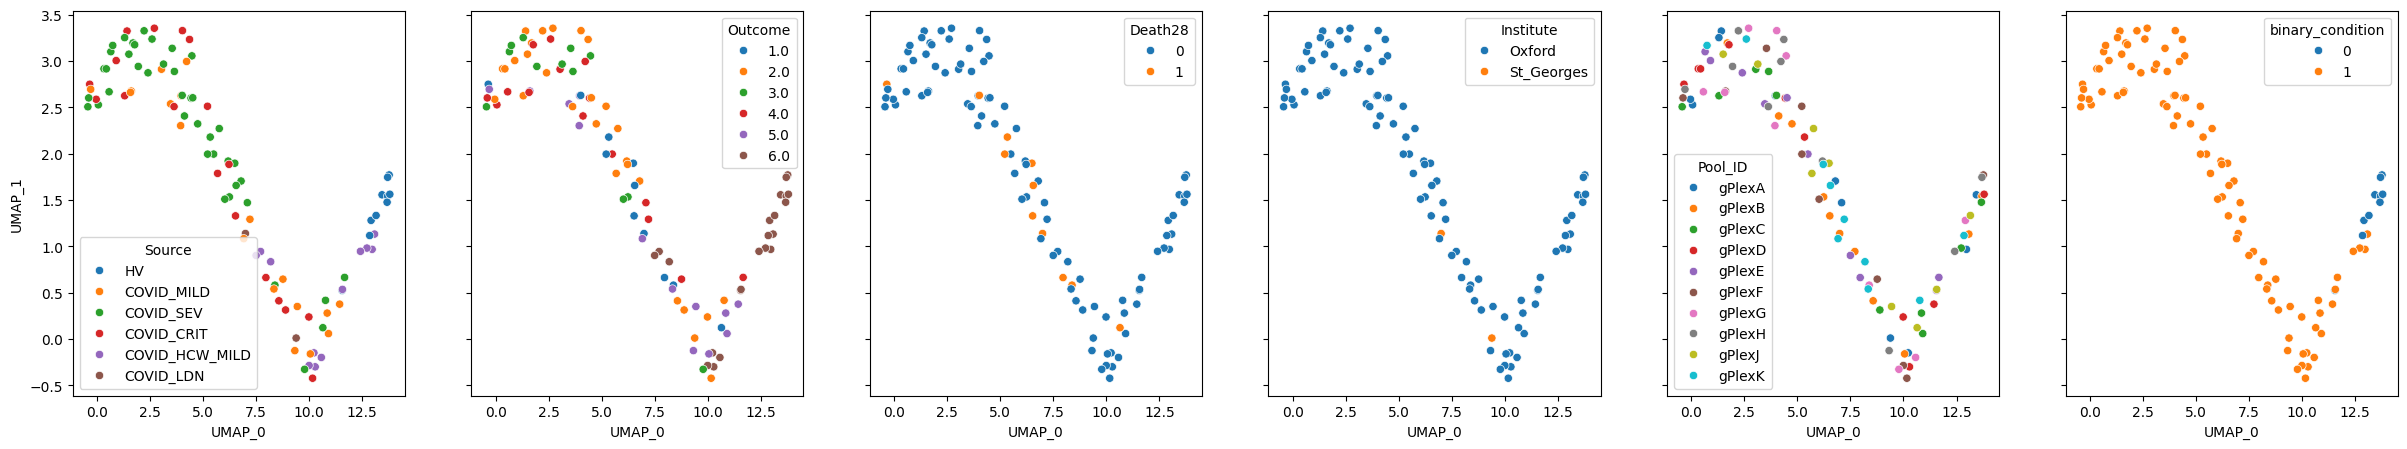

In [14]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

## Binary prediction

Fine-tune a linear probe on top of the learned representations and predict.

In [15]:
pascient.fine_tune("binary_condition", tasks="classification")

In [16]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.020635,0.979365,1
S00112-Ja003E-PBCa,0.005363,0.994637,1
S00005-Ja005E-PBCa,0.001747,0.998253,1
S00061-Ja003E-PBCa,0.000332,0.999668,1
S00056-Ja003E-PBCa,0.001728,0.998272,1
...,...,...,...
S00076-Ja001E-PBCa,0.050373,0.949627,1
S00072-Ja001E-PBCa,0.288159,0.711841,1
S00065-Ja003E-PBCa,0.013355,0.986645,1
S00048-Ja003E-PBCa,0.003283,0.996717,1


In [17]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        10
           1       1.00      0.95      0.97        91

    accuracy                           0.95       101
   macro avg       0.83      0.97      0.89       101
weighted avg       0.97      0.95      0.95       101



## Multiclass prediction

We can also fine-tune for the multiclass `Source` label.

In [18]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [19]:
pascient.fine_tune("Source", tasks="classification")

In [20]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.237926,0.101965,0.186137,0.220704,0.248978,0.004290,COVID_SEV
S00112-Ja003E-PBCa,0.277991,0.043071,0.176386,0.205490,0.296346,0.000717,COVID_SEV
S00005-Ja005E-PBCa,0.355116,0.019069,0.111965,0.151479,0.362221,0.000151,COVID_SEV
S00061-Ja003E-PBCa,0.342472,0.006021,0.059928,0.143261,0.448302,0.000016,COVID_SEV
S00056-Ja003E-PBCa,0.334972,0.021626,0.121166,0.164674,0.357407,0.000155,COVID_SEV
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.177883,0.182647,0.223087,0.236502,0.167242,0.012638,COVID_MILD
S00072-Ja001E-PBCa,0.088246,0.355125,0.180815,0.186296,0.073885,0.115633,COVID_HCW_MILD
S00065-Ja003E-PBCa,0.270455,0.082429,0.173039,0.225713,0.245987,0.002377,COVID_CRIT
S00048-Ja003E-PBCa,0.326279,0.027430,0.107085,0.178762,0.360087,0.000356,COVID_SEV


In [21]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.38      0.17      0.23        18
COVID_HCW_MILD       0.33      0.50      0.40        12
     COVID_LDN       0.67      1.00      0.80         2
    COVID_MILD       0.43      0.33      0.38        18
     COVID_SEV       0.63      0.71      0.67        41
            HV       0.75      0.90      0.82        10

      accuracy                           0.54       101
     macro avg       0.53      0.60      0.55       101
  weighted avg       0.53      0.54      0.52       101



## Sample and cell importance

PaSCient provides interpretability through importance scores. Sample importance is the L2 norm of the sample embedding; cell importance measures each cell's contribution to its sample's representation.

In [22]:
pascient_sample_importance = pascient.get_sample_importance()
pascient_sample_importance.head()

,average_importance,binary_condition_importance,Source_importance
S00109-Ja001E-PBCa,7.614018,7.614018,7.614018
S00112-Ja003E-PBCa,8.157110,8.157110,8.157110
S00005-Ja005E-PBCa,8.574222,8.574222,8.574222
S00061-Ja003E-PBCa,9.172144,9.172144,9.172144
S00056-Ja003E-PBCa,8.561299,8.561299,8.561299


In [23]:
pascient_cell_importance = pascient.get_cell_importance()
pascient_cell_importance.head()

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:2095: UserWarning: Using data from adata.X
  cell_data = self._get_data()[cell_mask]


,binary_condition_importance,Source_importance
AAACCTGAGAAAGTGG-1-gPlexA1,0.044646,0.044646
AAACCTGAGCGGATCA-1-gPlexA1,0.055360,0.055360
AAACCTGAGGCGACAT-1-gPlexA1,0.040201,0.040201
AAACCTGAGGGAACGG-1-gPlexA1,0.097973,0.097973
AAACCTGCACATGTGT-1-gPlexA1,0.081710,0.081710


## Recompute distances and visualize after fine-tuning

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


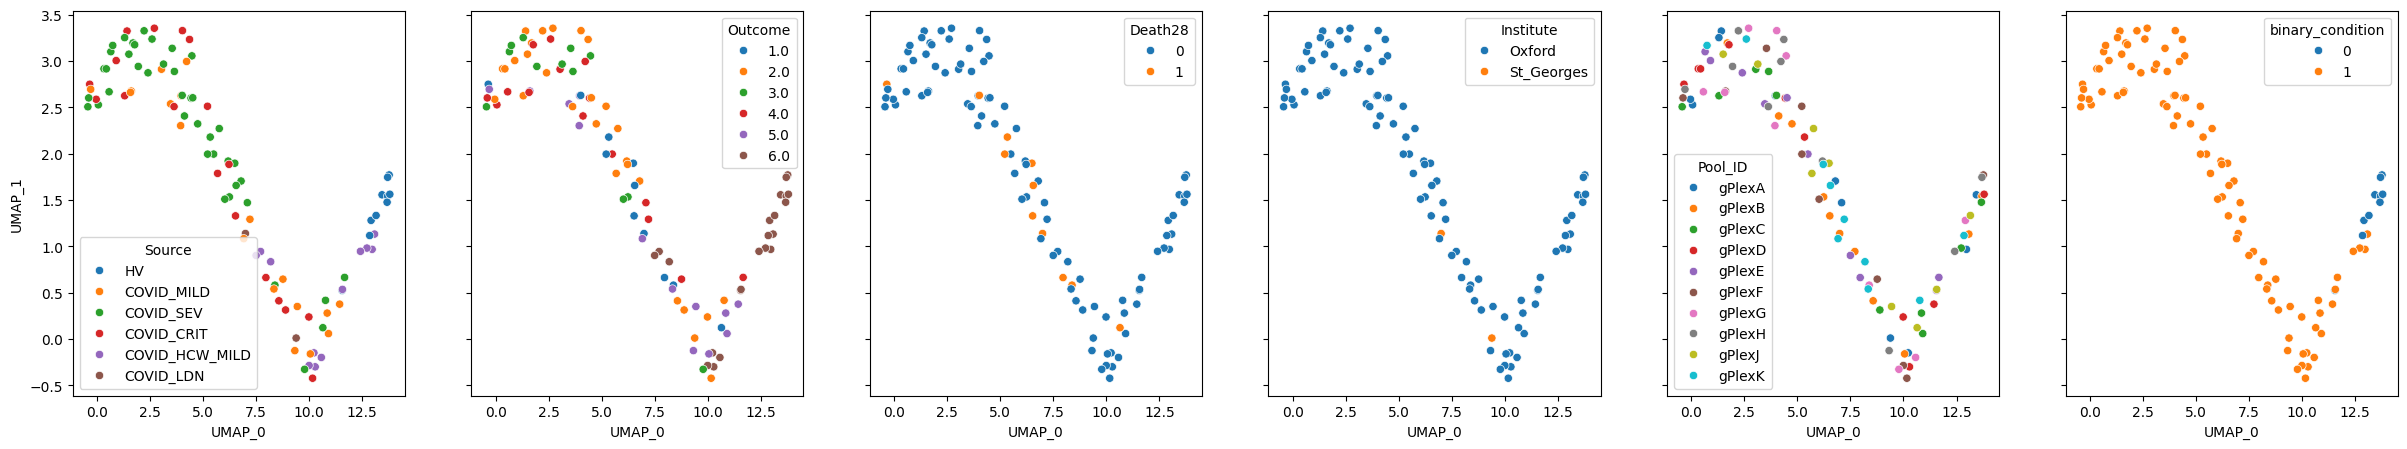

In [24]:
pascient.calculate_distance_matrix()
pascient.embed("UMAP")
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

In this tutorial you learned how to train PaSCient from scratch, extract sample representations, evaluate them, make binary and multiclass predictions, and compute importance scores with `patpy`.